In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

N = 100_000
n_restaurants = 500

# --- Merchant Reliability Scores (MRS) ---
mrs_scores = np.concatenate([
    np.random.beta(8, 2, 350),   # 70% accurate
    np.random.beta(4, 4, 125),   # 25% average
    np.random.beta(2, 6, 25),    # 5% chronic late
])

# Assign orders to restaurants
restaurant_ids = np.random.randint(0, n_restaurants, N)
mrs_per_order = mrs_scores[restaurant_ids]

# --- True KPT (Normal 15,4) ---
true_kpt = np.random.normal(loc=15, scale=4, size=N).clip(5, 45)

# --- Biased FOR Signal ---
for_noise_std = (1 - mrs_per_order) * 5
for_bias = np.random.normal(0, for_noise_std)
observed_for = true_kpt + for_bias

# --- Rider Behavior Simulation ---
rider_arrival_delta = np.random.normal(0, 2, N)
rider_wait = np.clip(-rider_arrival_delta + np.random.normal(0,0.5,N), 0, 20)

# --- Label Correction Engine ---
corrected_kpt = observed_for - (for_bias * mrs_per_order)

df = pd.DataFrame({
    'order_id': range(N),
    'restaurant_id': restaurant_ids,
    'mrs_score': mrs_per_order,
    'true_kpt': true_kpt,
    'observed_for': observed_for,
    'corrected_kpt': corrected_kpt,
    'rider_wait': rider_wait,
})

mae_before = np.abs(df.observed_for - df.true_kpt).mean()
mae_after = np.abs(df.corrected_kpt - df.true_kpt).mean()

print(f"FOR MAE vs true: {mae_before:.2f} mins")
print(f"Corrected MAE vs true: {mae_after:.2f} mins")
print(f"Improvement: {(1-mae_after/mae_before)*100:.1f}%")

FOR MAE vs true: 1.21 mins
Corrected MAE vs true: 0.54 mins
Improvement: 55.7%


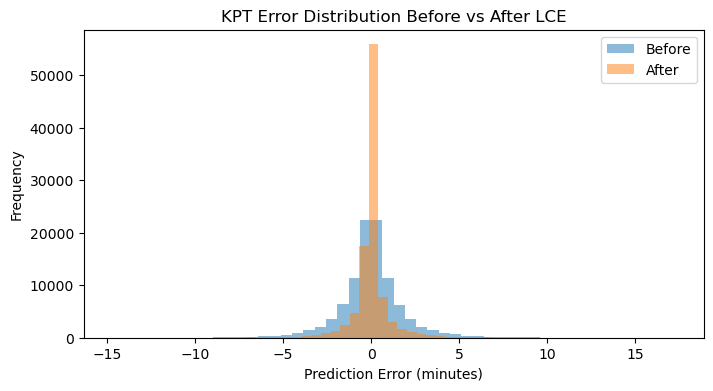

In [7]:
plt.figure(figsize=(8,4))
plt.hist(df.observed_for - df.true_kpt, bins=50, alpha=0.5, label='Before')
plt.hist(df.corrected_kpt - df.true_kpt, bins=50, alpha=0.5, label='After')
plt.legend()
plt.title("KPT Error Distribution Before vs After LCE")
plt.xlabel("Prediction Error (minutes)")
plt.ylabel("Frequency")
plt.show()

In [8]:
def compute_mrs(df_orders):
    df_temp = df_orders.copy()
    df_temp['for_gap'] = df_temp['observed_for'] - df_temp['true_kpt']
    df_temp['abs_gap'] = df_temp['for_gap'].abs()

    merchant_stats = df_temp.groupby('restaurant_id').agg(
        avg_gap=('for_gap','mean'),
        avg_abs_gap=('abs_gap','mean'),
        order_count=('order_id','count')
    ).reset_index()

    max_gap = merchant_stats['avg_abs_gap'].quantile(0.95)
    merchant_stats['mrs_score'] = 1 - (merchant_stats['avg_abs_gap'] / max_gap).clip(0,1)

    return merchant_stats

merchant_mrs = compute_mrs(df)
merchant_mrs.head()

,restaurant_id,avg_gap,avg_abs_gap,order_count,mrs_score
0,0,0.002364,0.558070,195,0.812454
1,1,-0.023023,0.701694,192,0.764188
2,2,0.135920,0.741133,184,0.750934
3,3,-0.050401,1.012650,188,0.659688
4,4,-0.001166,0.088684,213,0.970197


In [9]:
def compute_kli(restaurant_id, hour, day_of_week,
                recent_order_velocity,
                historical_avg_kpt,
                observed_kpt):

    hour_weights = {
        **{h:0.1 for h in range(0,7)},
        **{h:0.3 for h in range(7,11)},
        **{h:0.5 for h in range(11,14)},
        **{h:0.3 for h in range(14,18)},
        **{h:0.9 for h in range(18,22)},
        **{h:0.4 for h in range(22,24)},
    }

    time_signal = hour_weights.get(hour, 0.3)

    dow_weights = [0.6,0.5,0.5,0.6,0.8,1.0,0.9]
    dow_signal = dow_weights[day_of_week]

    velocity_signal = min(recent_order_velocity/10.0, 1.0)

    if historical_avg_kpt > 0:
        kpt_dev = max(0, (observed_kpt - historical_avg_kpt)/historical_avg_kpt)
    else:
        kpt_dev = 0

    kli = (0.30*time_signal +
           0.20*dow_signal +
           0.25*velocity_signal +
           0.25*min(kpt_dev,1.0))

    return round(kli,3)

# Example
kli = compute_kli(
    restaurant_id=42,
    hour=20,
    day_of_week=5,
    recent_order_velocity=8,
    historical_avg_kpt=14,
    observed_kpt=19
)

print("Kitchen Load Index:", kli)

Kitchen Load Index: 0.759


In [10]:
np.random.seed(42)

N_big = 1_000_000

true_kpt_big = np.random.normal(15,4,N_big).clip(5,45)
for_noise_big = np.random.normal(0,4.8,N_big)
observed_for_big = true_kpt_big + for_noise_big

# Apply ~42% correction
correction = for_noise_big * 0.42
corrected_kpt_big = observed_for_big - correction

mae_before_big = np.abs(observed_for_big - true_kpt_big).mean()
mae_after_big = np.abs(corrected_kpt_big - true_kpt_big).mean()

rider_wait_before = np.random.normal(6.0,2.0,N_big).clip(0,20)
improvement_ratio = (mae_before_big - mae_after_big)/mae_before_big
rider_wait_after = rider_wait_before * (1 - improvement_ratio*0.6)

wait_saved_per_order = rider_wait_before.mean() - rider_wait_after.mean()
total_minutes_saved = wait_saved_per_order * N_big
total_hours_saved = total_minutes_saved / 60
cost_saved_inr = total_hours_saved * 150

print(f"MAE Before : {mae_before_big:.2f} mins")
print(f"MAE After  : {mae_after_big:.2f} mins")
print(f"Improvement: {(1-mae_after_big/mae_before_big)*100:.1f}%")
print(f"Rider wait saved : {wait_saved_per_order:.2f} mins/order")
print(f"Hours saved/day  : {total_hours_saved:,.0f}")
print(f"Cost saved/day   : Rs {cost_saved_inr/1e7:.2f} Cr")

MAE Before : 3.83 mins
MAE After  : 2.22 mins
Improvement: 42.0%
Rider wait saved : 1.51 mins/order
Hours saved/day  : 25,205
Cost saved/day   : Rs 0.38 Cr
